# **Petike és a Paraméteres Paletta**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>MI Országos Diákolimpia Válogató</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Computer Vision</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>100 pont</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>2025. Május 24.</span>
  </div>
</div>

**Név:** [ÍRD IDE A NEVED]

**Versenyzői Azonosító:** [ÍRD IDE A VERSENYZŐI AZONOSÍTÓD]

<img src="https://drive.google.com/uc?export=view&id=1zqzy6u66LW5HzD6gEpZRpXO1Mpi8KG_z" alt="petike" style="width:150px;">

Petike kis csoportos óvodás. Kedvenc elfoglaltsága a rajzolás. Nemrég ismerkedett meg az alapformákkal (**körrel, négyzettel és háromszöggel**), és nagyon lelkes, ha ezekből készíthet rajzokat.

Mostanra azonban a tanítási időszak lezárult. Petike már nem tanul új példákból, csak azt tudja, amit a korábbi rajzai alapján megtanult. Ha most valamit szeretnénk tőle, **a látens terén keresztül tudjuk megkérni**.

Ebben a feladatban az a célod, hogy a látens térben olyan pontokat találj, amelyek alapján Petike szép és változatos rajzokat készít.

Petike kis csoportos óvodás. Kedvenc elfoglaltsága a rajzolás. Nemrég ismerkedett meg az alapformákkal (**körrel, négyzettel és háromszöggel**), és nagyon lelkes, ha ezekből készíthet rajzokat. Az óvodában azonban kevés színű zsírkréta van, így Petike eddig csak **pirosat, kéket és zöldet** használt. Minden elkészült rajzát odaadja az óvónéninek, aki segít neki egyre szebben rajzolni.

Az óvónéni viszont különös lény: nem szól egy szót sem, de mindig pontosan tudja, mennyire sikerült jól a rajz, és ezt Petike is érzi. Valójában az óvónéni nem más, mint egy **loss function**, aki minden rajz után csendben, de határozottan visszajelzi Petikének, hogy mennyire volt ügyes. Petike így tanult meg formákat rajzolni a tanítás során.

Mostanra azonban a tanítási időszak lezárult. Petike már nem tanul új példákból, csak azt tudja, amit a korábbi rajzai alapján megtanult. De továbbra is lehet vele kommunikálni, csak nem úgy, ahogy egy átlagos óvodással.

Petikét ugyanis nem lehet közvetlenül utasítani, és nem ért új példákból sem. Egyetlen módon érthetjük meg egymást: **a látens térén keresztül**. Ha ott megadunk neki egy pontot, Petike azt egy rajzzá alakítja a saját stílusában.

<ins>Szerencsére van néhány eszközünk a kezünkben</ins>:

- **Petike dekódere**: ebből tudjuk, hogy egy adott látens pont alapján mit fog rajzolni;

- **Petike enkódere**: ezzel meglévő rajzokat tudunk leképezni a látens térbe, így például ha mutatunk neki egy példát (pl. egy piros négyzetet), megtudhatjuk, hogy ezt Petike hol „képzeli el” a látens térben;

- **Petike külső osztályozói**: amellett, hogy Petike lerajzolja, amit a látens térben elképzel, emellett rá is tud mutatni, hogy mit szeretett volna lerajzolni.

<ins>**A feladat:**</ins>

Magyarázd el Petikének a látens téren keresztül, hogy rajzoljon:

- **5 különböző magenta színű kört**
- **5 különböző narancssárga háromszöget**
- **5 különböző képet, amin megjelenik a kék szín**

## **Hasznos linkek**

- [What is a variational autoencoder?](https://www.ibm.com/think/topics/variational-autoencoder)
- [PyTorch](https://docs.pytorch.org/docs/stable/index.html)
- [Pillow](https://pillow.readthedocs.io/en/stable/)
- [numpy](https://numpy.org/doc/stable/)
- [matplotlib](https://matplotlib.org/stable/users/index.html)

## **Szükséges Importok**

Importáltunk néhány könyvtárat a kezdéshez, de nyugodtan használhatsz bármilyen PyTorch-alapú eszközt, ha szükséges. Kérjük, vedd figyelembe, hogy a Keras és a TensorFlow **NEM ENGEDÉLYEZETT** ennek a feladatnak a megoldásához!

In [ ]:
!pip install --q torchview

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageDraw
from torchview import draw_graph
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## **Petike felépítése**

**Segítség**: Petike úgy gondolkozik, mint egy Variational Autoencoder.

A **variációs autoenkóder (VAE)** egy olyan mesterséges neurális hálózat, amelyet képek (vagy más adatok) generálására használnak. A lényege, hogy megtanulja, hogyan lehet egy képet egyszerűbb, tömör formában (a látens térben) ábrázolni, majd ebből a belső reprezentációból újraalkotni a képet.

A VAE:
- egy **enkóderből** áll (amely a képből a látens térbe ugrik),
- egy **dekóderből** (amely a látens térből képet generál),
- és egy **speciális tanítási módszert** alkalmaz, ahol nem egyetlen pontot, hanem valószínűségi eloszlásokat tanulunk meg.

Ez lehetővé teszi, hogy a modell „képzelőereje” is legyen: képes olyan új képeket létrehozni, amelyeket sosem látott, de illenek a tanult mintákhoz.

In [ ]:
LATENT_DIM = 3
LATENT_FEATURE_SIZE = LATENT_DIM * 4 * 4

class Petike(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, device=None):
        super(Petike, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.flatten = nn.Flatten()
        self.fc_mu = nn.Linear(128 * 4 * 4, LATENT_FEATURE_SIZE)
        self.fc_logvar = nn.Linear(128 * 4 * 4, LATENT_FEATURE_SIZE)

        self.decoder_input = nn.Linear(LATENT_FEATURE_SIZE, LATENT_FEATURE_SIZE)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (latent_dim, 4, 4)),
            nn.ConvTranspose2d(latent_dim, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, 2, 1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Sigmoid()
        )

        self.register_buffer("shape_input", torch.zeros(LATENT_FEATURE_SIZE))
        self.shape_input[0:24] = 1.0

        self.register_buffer("color_input", torch.zeros(LATENT_FEATURE_SIZE))
        self.color_input[24:48] = 1.0

        for i in [0, 12, 24, 36]:
            self.color_input[i] = 0.0
            self.shape_input[i] = 0.0

        self.shape_classifier = nn.Sequential(
            nn.Linear(LATENT_FEATURE_SIZE, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
        self.color_classifier = nn.Sequential(
            nn.Linear(LATENT_FEATURE_SIZE, 16),
            nn.ReLU(),
            nn.Linear(16, 3)
        )
        self.size_regressor = nn.Sequential(
            nn.Linear(LATENT_FEATURE_SIZE, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

        self.mask_head = nn.Sequential(
            nn.Linear(LATENT_FEATURE_SIZE, 48),
            nn.ReLU(),
            nn.Linear(48, 32 * 32),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar


    def decode(self, z):
        x = self.decoder_input(z)
        return self.decoder(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        shape_logits = self.shape_classifier(z * self.shape_input)
        color_logits = self.color_classifier(z * self.color_input)
        size_pred = self.size_regressor(z).squeeze(1)
        mask_pred = self.mask_head(z).view(-1, 1, 32, 32)
        return recon, mu, logvar, shape_logits, color_logits, size_pred, mask_pred

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def l1_latent_regularization(self):
        l1 = 0.
        for layer in [self.fc_mu, self.decoder_input]:
            for param in layer.parameters():
                l1 += param.abs().sum()
        return l1

    def l1_classifier_regularization(self):
        l1 = 0.
        for classifier in [self.shape_classifier, self.color_classifier, self.size_regressor]:
            for param in classifier.parameters():
                l1 += param.abs().sum()
        return l1

## **Néhány példa Petike rajzaiból**

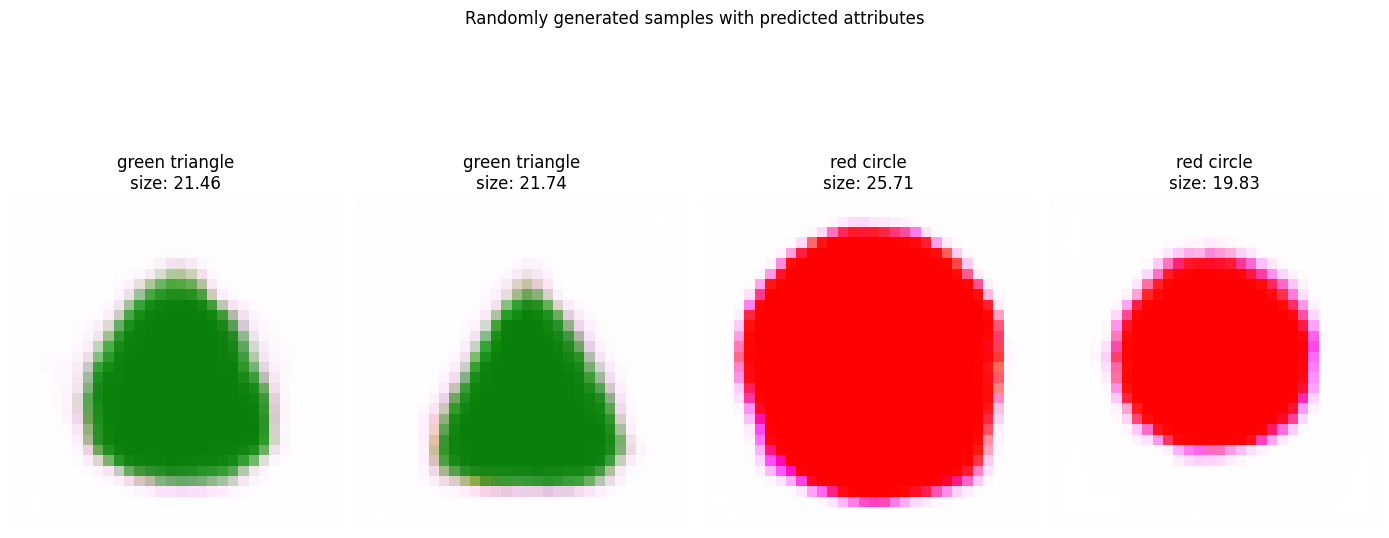

## **Petike letöltése**

A következő lépésben letöltjük Petike modelljét, hogy használni tudjuk a látens térrel való kísérletezéshez. Ez a modell már előre betanított, így azonnal használható képgenerálásra, kódolásra és osztályozásra is.

In [ ]:
!gdown 1wuYIUV9rp-OeSWDSrTllmrTt50YzbxxP

Downloading...
From: https://drive.google.com/uc?id=1wuYIUV9rp-OeSWDSrTllmrTt50YzbxxP
To: /content/petike.pth
100% 1.89M/1.89M [00:00<00:00, 97.4MB/s]


## **Petike inicializálása**

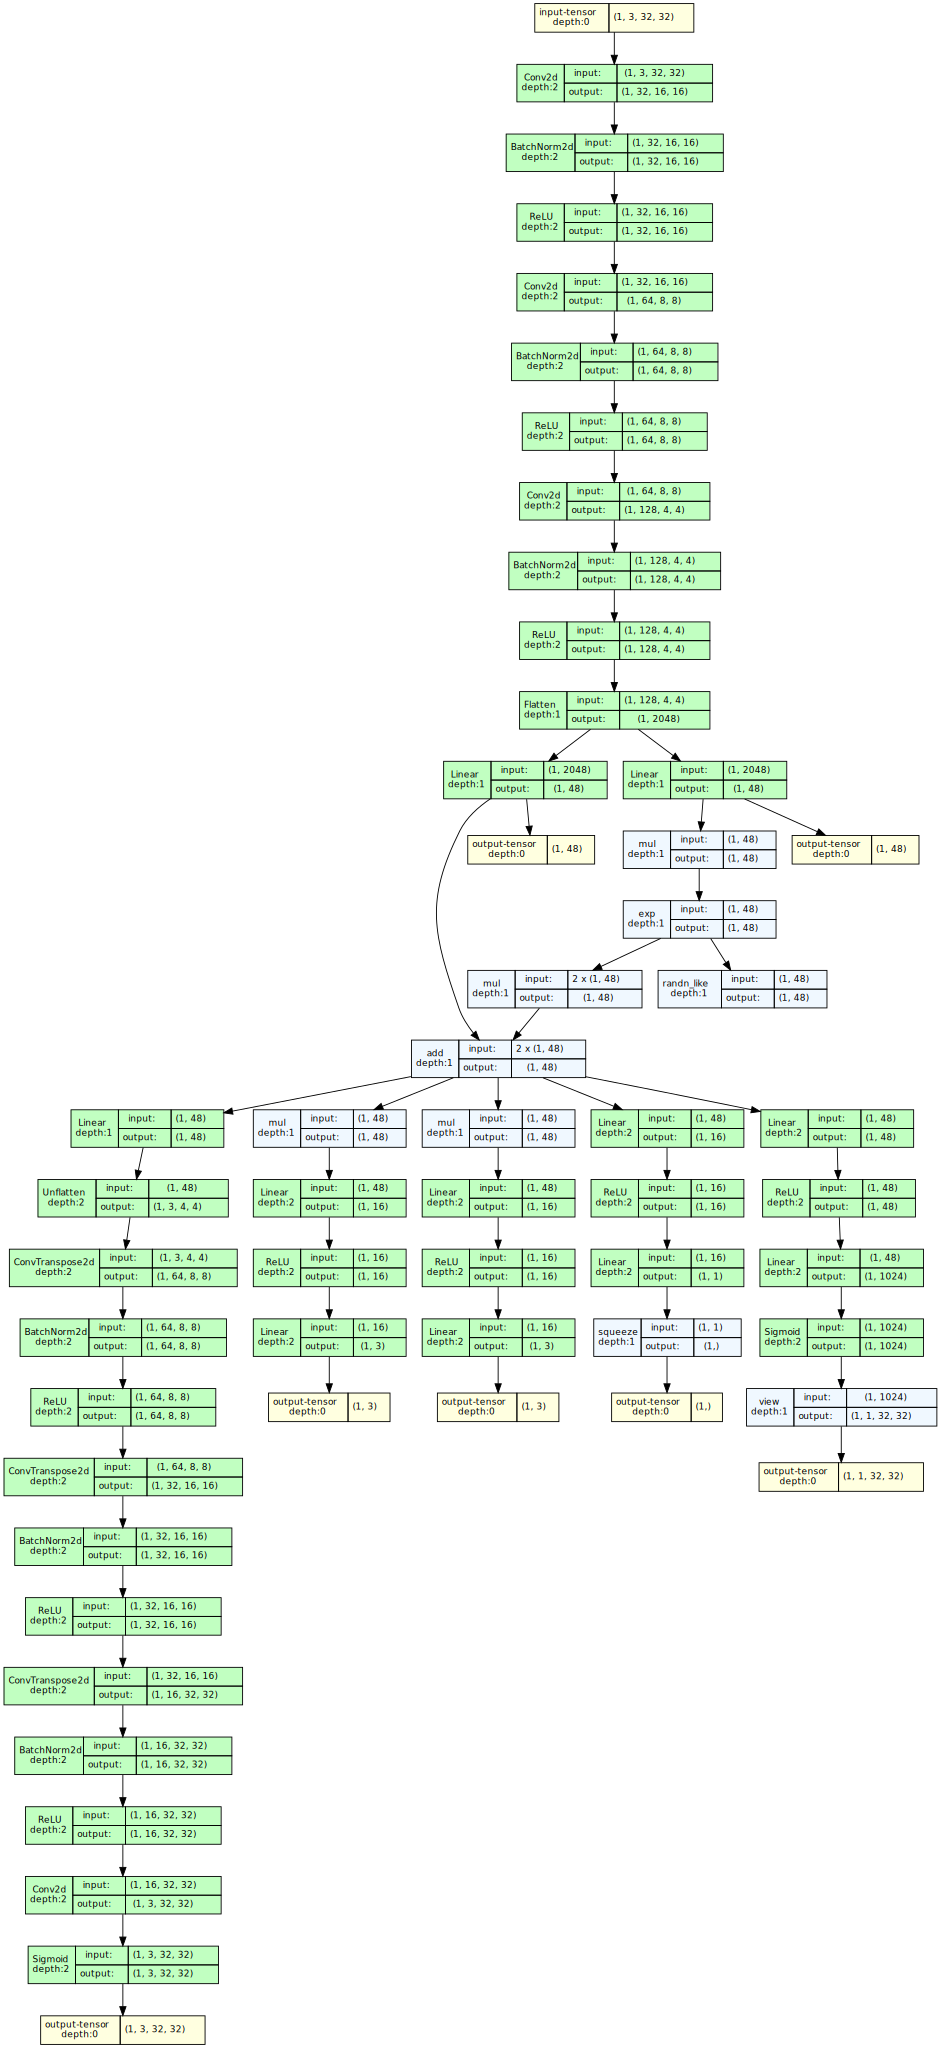

In [ ]:
petike = Petike().to(device)
petike.load_state_dict(torch.load("petike.pth", map_location=torch.device(device)))

model_graph = draw_graph(petike, input_size=(1,3,32,32), expand_nested=False)
model_graph.visual_graph

# **1. Feladat - Segédfüggvények (25 pont)**

Az alábbi függvényeket Petike generatív modelljének használatához kaptad. Ezek segítenek abban, hogy képeket alakíts át látens reprezentációvá, majd vissza,  illetve új képeket generálj pusztán a látens tér segítségével.

---

### `image_to_tensor(img)`

Ez a függvény egy `PIL.Image` típusú képet PyTorch tenzorrá alakít, amit a modell már képes értelmezni. Ez azt jelenti, hogy:
- átalakítja a képet egy `[C, H, W]` formátumú tömbbé (színcsatornák, magasság, szélesség),
- normalizálja az értékeket 0 és 1 közé,
- hozzáad egy "batch" dimenziót, így `[1, C, H, W]` alakú lesz.

---

### `tensor_to_image(tensor)`

Ennek a függvénynek a segítségével egy PyTorch tensorból újra képet készíthetsz (`PIL.Image` formátumban), amit meg is tudsz jeleníteni. Ez az ellenkezője az előző lépésnek.

---

### `draw_shape(shape, size, position, color)`

Ez a függvény egy **32x32 pixeles rajzlapra** rajzol egy alakzatot:
- `shape`: lehet `'circle'`, `'square'` vagy `'triangle'`
- `size`: a forma mérete pixelben
- `position`: a bal felső sarok `(x, y)` koordinátája
- `color`: a szín, pl. `'red'`, `'blue'`, vagy `(255, 165, 0)` (RGB)

Ez hasznos lehet példaképek készítéséhez vagy teszteléshez!

---

### `reconstruct(model, batch)`

Ezzel a függvénnyel vissza tudod állítani egy bemeneti kép rekonstrukcióját a modell segítségével. A modell először lekódolja a képet a látens térbe, majd dekódolja vissza képpé. Így ellenőrizheted, mennyire „emlékszik” Petike az adott képre.

---

### `encode(model, batch)`

Ez a függvény lekódolja a képeidet a **látens térbe**. A kimenet egy olyan vektor, ami tömören leírja, hogy Petike szerint mi van a képen. Ezekkel a vektorokkal lehet majd **manipulálni** vagy új képeket generálni.

---

### `decode(model, latent_vector)`

Ez pedig az előző ellentettje: egy látens vektorból **új képet generál**. Ezzel tudod „megkérni” Petikét, hogy rajzoljon valamit. Ha jól választod meg a látens pontokat, szép és változatos képeket készít!


## **Implentáld az alábbi segédfüggvényeket, amelyek a feladat megoldásában segítenek.**

In [ ]:
def image_to_tensor(img):
    """
    Convert a PIL image to a tensor and normalize it.
    Args:
        img (PIL.Image): Input image.
    Returns:
        torch.Tensor: Normalized tensor representation of the image with shape (B, C, H, W).
    """
    # --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~2-3 sor)

    pass
    # ----------- ITT A MEGOLDÁSOD VÉGE -------------


def tensor_to_image(tensor):
    """
    Convert a tensor to a PIL image.
    Args:
        tensor (torch.Tensor): Input tensor with shape (B, C, H, W).
    Returns:
        PIL.Image: Image representation of the tensor.
    """
    # --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~2-3 sor)

    pass
    # ----------- ITT A MEGOLDÁSOD VÉGE -------------


def draw_shape(shape, size, position, color):
    """
    Draw a shape on a blank image with size 32x32.
    Args:
        draw (PIL.ImageDraw): ImageDraw object to draw on.
        shape (str): Shape type ('triangle', 'square', 'circle').
        size (int): Size of the shape.
        position (tuple): Position (x, y) to draw the shape.
        color (tuple): Color of the shape (R, G, B) or string literals like ('red', 'blue', 'green').
    """
    # --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~12-14 sor)

    pass
    # ----------- ITT A MEGOLDÁSOD VÉGE -------------


def reconstruct(model, batch):
    """
    Reconstruct the input batch using the loaded model.
    Args:
        batch (torch.Tensor): Input batch of images.
    Returns:
        torch.Tensor: Reconstructed images.
    """
    # --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~5-6 sor)

    pass
    # ----------- ITT A MEGOLDÁSOD VÉGE -------------


def encode(model, batch):
    """
    Encode the input batch using the loaded model.
    Args:
        batch (torch.Tensor): Input batch of images with shape (B, C, H, W).
    Returns:
        torch.Tensor: Encoded latent vectors.
    """
    # --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~5-6 sor)

    pass
    # ----------- ITT A MEGOLDÁSOD VÉGE -------------


def decode(model, latent_vector):
    """
    Decode the latent vector using the loaded model.
    Args:
        latent_vector (torch.Tensor): Latent vector to decode with shape (B, 48).
    Returns:
        torch.Tensor: Reconstructed images.
    """
    # --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~4-5 sor)

    pass
    # ----------- ITT A MEGOLDÁSOD VÉGE -------------

In [ ]:
# --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~20-30 sor)

# ----------- ITT A MEGOLDÁSOD VÉGE -------------

# **2. Feladat (25 pont)**

Most arra kérjük Petikét, hogy rajzoljon egy magenta színű kört.

Ehhez először készítsünk egy példaképet ilyen körrel, majd kódoljuk be a látens térbe. A látens reprezentáció alapján Petike megpróbálja visszaadni, mit értett belőle.

Figyeld meg, mennyire sikerül megtartania a kört és a magenta színt a rekonstrukcióban. Ha szeretnéd, próbálkozhatsz különböző méretű vagy elhelyezkedésű körökkel is.

Kevesebb helyes ábra megjelenítése esetén részpontszám adható!

# **3. Feladat (25 pont)**

Ebben a feladatban Petikét arra kérjük, hogy rajzoljon egy narancssárga háromszöget.

Először rajzoljunk egy példaképet, majd alakítsuk át olyan formára, amit Petike ért. Ezt be tudjuk kódolni a látens térbe, majd visszafejtve újra megkérjük őt, hogy rajzolja meg.

A cél az, hogy megnézzük, Petike mennyire tudja visszaadni a forma és szín lényegét. Érdemes többféle mérettel és pozícióval is kísérletezni.

Kevesebb helyes ábra megjelenítése esetén részpontszám adható!

In [ ]:
# --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~20-30 sor)

# ----------- ITT A MEGOLDÁSOD VÉGE -------------

# **4. Feladat (25 pont)**

Ebben a feladatban az a cél, hogy Petike olyan képet rajzoljon, amelyen minimálisan megjelenik a kék szín.

Petike ritkán használja a kéket, így nem biztos, hogy magától szívesen választja ezt. Segíthetünk neki, ha olyan példaképet mutatunk, amin kék forma szerepel, így a látens térben is megerősödik ennek a jelentősége.

Érdemes kísérletezni különféle kék színű formákkal, és megfigyelni, hogy Petike milyen mértékben képes ezt visszaadni a rajzaiban.

Kevesebb helyes ábra megjelenítése esetén részpontszám adható!

In [ ]:
# --------- IDE KERÜL A SAJÁT MEGOLDÁSOD --------- (~20-30 sor)

# ----------- ITT A MEGOLDÁSOD VÉGE -------------

---

## 🎉 Gratulálunk!

A feladatsor végére értél - kiváló munkát végeztél!  

---